In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import petab
import seaborn as sns

_project_root = str(
    next(
        (
            _p
            for _p in (Path.cwd(), *Path.cwd().parents)
            if (_p / "common.py").is_file()
        ),
        Path.cwd().parent,
    )
)
if _project_root not in sys.path:
    sys.path.insert(0, _project_root)

from sklearn.decomposition import PCA
from sklearn.impute import KNNImputer

from cytof import get_samples
from dmm.config_options import Conf
from dmm.feature_selection import (
    contextualize_measurements,
    harmonise_cytof_dynamic,
)
from util import load_petab_base_files

DATA = "dream_cytof"
MODEL = "EGFR_MAPK__logobs"

# updated load_petab_base_files takes in a Conf object as argument
conf = Conf(model=MODEL, data=DATA)
files = load_petab_base_files(conf)
# Get the list of all cell-lines APART from test cell-lines
all_samples = sorted(get_samples(conf.data)[:-5])
print(len(all_samples))

58


In [2]:
all_samples

['c184A1',
 'c184B5',
 'cAU565',
 'cBT20',
 'cBT474',
 'cBT483',
 'cBT549',
 'cCAL148',
 'cCAL51',
 'cCAL851',
 'cDU4475',
 'cEFM19',
 'cEFM192A',
 'cEVSAT',
 'cHBL100',
 'cHCC1187',
 'cHCC1395',
 'cHCC1419',
 'cHCC1428',
 'cHCC1500',
 'cHCC1569',
 'cHCC1806',
 'cHCC1937',
 'cHCC1954',
 'cHCC202',
 'cHCC2185',
 'cHCC2218',
 'cHCC3153',
 'cHCC38',
 'cHCC70',
 'cHDQP1',
 'cHs578T',
 'cJIMT1',
 'cLY2',
 'cMACLS2',
 'cMCF10A',
 'cMCF12A',
 'cMCF7',
 'cMDAMB134VI',
 'cMDAMB157',
 'cMDAMB175VII',
 'cMDAMB231',
 'cMDAMB361',
 'cMDAMB415',
 'cMDAMB436',
 'cMDAMB453',
 'cMDAMB468',
 'cMFM223',
 'cMPE600',
 'cMX1',
 'cOCUBM',
 'cSKBR3',
 'cT47D',
 'cUACC3199',
 'cUACC812',
 'cUACC893',
 'cZR751',
 'cZR7530']

In [3]:
mat, _ = contextualize_measurements(
    measurement_table=files["measurement_table"],
    observable_table=files["observable_table"],
    contextualization="cytof_dynamic",
    samples=all_samples,  # no cell-line subsetting - keep all
    impute=False
)

# contextualize_measurements() only pivots the raw measurements. Training
# normally calls harmonise_cytof_dynamic() afterwards via load_data().
interpolate_timepoints = True
if interpolate_timepoints:
    mat = harmonise_cytof_dynamic(mat)

print(mat.index.nunique())


# filter out columns with less than 3 datapoints
mat = mat.loc[:, mat.notna().sum(axis=0) >= 3]

58


In [4]:
subset_to_EGF = False
if subset_to_EGF:
    mat = mat[[col for col in mat.columns if col[1] == "EGF"]]

# Toggle this to impute and keep (True) / drop (False) pHER2
impute_missing = True
if impute_missing:
    knn_imputer = KNNImputer()
    knn_imputer.fit(mat)
    mat = pd.DataFrame(
        knn_imputer.transform(mat),
        columns=mat.columns,
        index=mat.index
    )

In [5]:
perbb2 = mat.loc[:, mat.columns.get_level_values(0).str.contains("pERBB2")]
perbb2.index.name = "cell_line"   # just to have a nice name
long = (
    perbb2
      .stack(level=list(range(perbb2.columns.nlevels)))   # collapse all column levels
      .rename("value")
      .reset_index()
)

long

/var/folders/lt/n6z6ygk55q583z32lhqt4x8mg_mvwv/T/ipykernel_5225/3108697993.py:5: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  .stack(level=list(range(perbb2.columns.nlevels)))   # collapse all column levels


,cell_line,observableId,simulationConditionId,time,value
0,c184A1,pERBB2_Y1248_obs,EGF,0.0,4.166056
1,c184A1,pERBB2_Y1248_obs,EGF,5.5,4.199643
2,c184A1,pERBB2_Y1248_obs,EGF,7.0,4.492903
3,c184A1,pERBB2_Y1248_obs,EGF,9.0,4.669069
4,c184A1,pERBB2_Y1248_obs,EGF,13.0,4.372289
...,...,...,...,...,...
1387,cZR7530,pERBB2_Y1248_obs,iMEK,9.0,5.312412
1388,cZR7530,pERBB2_Y1248_obs,iMEK,13.0,4.828911
1389,cZR7530,pERBB2_Y1248_obs,iMEK,17.0,4.818105
1390,cZR7530,pERBB2_Y1248_obs,iMEK,40.0,4.908143


<Axes: xlabel='observableId-simulationConditionId-time', ylabel='cell_line'>

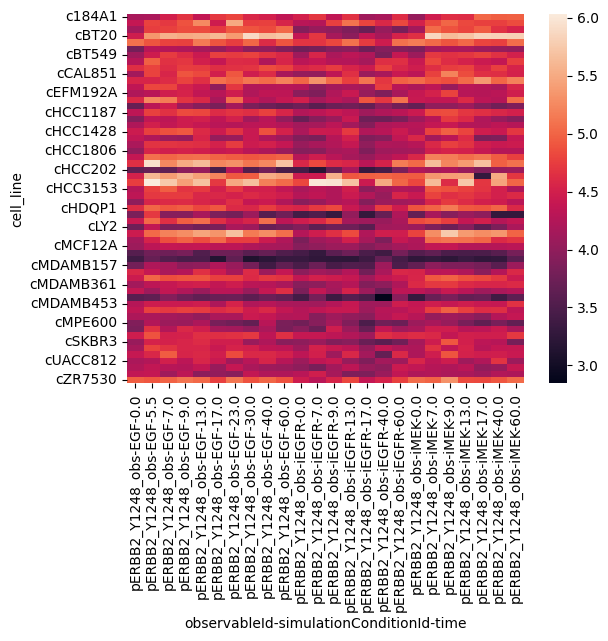

In [6]:
sns.heatmap(perbb2, xticklabels=True)

In [7]:
mat_nonans = mat.dropna(how="any", axis=1)

In [8]:
mat_nonans.shape

(58, 96)

In [9]:
res = (mat_nonans - mat_nonans.mean(axis=0)).apply(lambda x: np.power(x, 2)).mean(axis=1)
res.sort_values(ascending=False).head(10)
# top 5 cell-lines for deviation from the mean AFTER outlier: cHCC2185, cHCC1500, cUACC3199, cMCF7, cUACC893

cell_line
cHCC1500       0.964132
cHCC2185       0.900372
cMCF7          0.772677
cBT20          0.721440
cUACC893       0.696014
cUACC3199      0.691187
cEVSAT         0.668482
cHCC1954       0.639793
cMDAMB134VI    0.539990
cHCC202        0.507158
dtype: float64

In [10]:
print(res.sort_values(ascending=False).head(10).index.values)

['cHCC1500' 'cHCC2185' 'cMCF7' 'cBT20' 'cUACC893' 'cUACC3199' 'cEVSAT'
 'cHCC1954' 'cMDAMB134VI' 'cHCC202']


<Axes: ylabel='Frequency'>

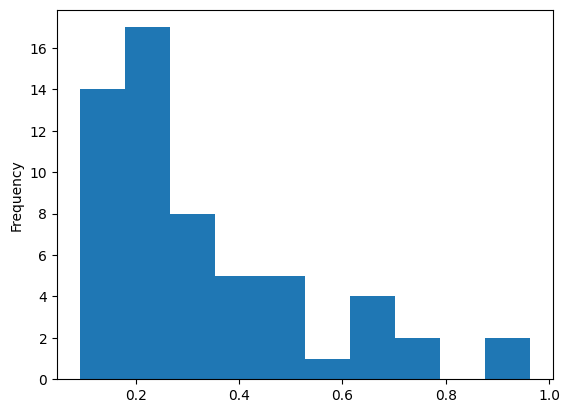

In [11]:
res.plot.hist()

In [12]:
mat.shape

(58, 96)

## After removing outlier HCC1599, mean changes so exact order of hardest cell-lines changes, but top 5 are the same cell-lines: HCC1500, HCC2185, MCF7, UACC3199 and BT20.

In [13]:
mat_nonans = mat.dropna(how="any", axis=1)
res = (mat_nonans - mat_nonans.mean(axis=0)).apply(lambda x: np.power(x, 2)).mean(axis=1)
res.sort_values(ascending=False).head(10)

cell_line
cHCC1500       0.964132
cHCC2185       0.900372
cMCF7          0.772677
cBT20          0.721440
cUACC893       0.696014
cUACC3199      0.691187
cEVSAT         0.668482
cHCC1954       0.639793
cMDAMB134VI    0.539990
cHCC202        0.507158
dtype: float64

# Inspect PCA

In [14]:
X = mat.values
# impute missing values prior to PCA
X_imputed = KNNImputer().fit_transform(X)

pca = PCA(n_components=10)
Xt = pca.fit_transform(X_imputed)

In [15]:
Xt.shape  # it appears 3 other cell-lines have been dropped (no transcriptomic data), previous notebook had 43 remaining cell-lines

(58, 10)

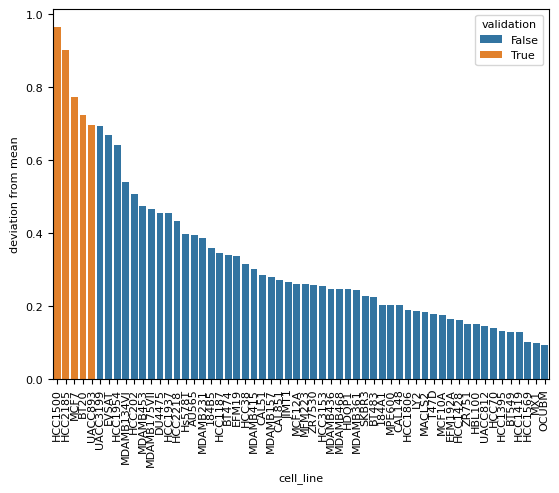

In [16]:
plt.rcParams.update({'font.size': 8})
res.name = "deviation from mean"
res.index.name = "cell_line"
res_df = res.reset_index()
res_df[res.index.name] = res_df[res.index.name].apply(lambda x: x[1:])
threshold = res.sort_values(ascending=False).head(5).min()
res_df["validation"] = res_df[res.name] >= threshold
res_df.sort_values(res.name, ascending=False, inplace=True)
sns.barplot(res_df, x=res.index.name, y=res.name, hue="validation", dodge=False)
# rotate x-axis labels
plt.xticks(rotation=90)
# decrease font size
res_df.set_index(res.index.name, inplace=True)

In [17]:
N_COMPS = 2
df = pd.DataFrame(
    index=[c[1:] for c in mat.index],
    data=Xt[:, :N_COMPS],
    columns=["PC1", "PC2"],
)
df.index.name = res.index.name
# select 5 strongest outliers as validation set
df["validation"] = res_df["validation"]
df

,PC1,PC2,validation
cell_line,,,
184A1,-2.301957,1.360556,False
184B5,-1.926066,3.831952,False
AU565,5.098353,0.117923,False
BT20,6.716192,2.884347,True
BT474,-3.738563,3.366346,False
BT483,-2.262056,-2.566516,False
BT549,-0.449720,0.134997,False
CAL148,-0.419246,1.173400,False
CAL51,4.039650,-0.669601,False


In [18]:
# Manually define annotation offsets to be able to read cell-line names
offsets = {
    # "HCC1599": {"ox": -1.7, "oy": -0.2},
    "MCF7": {"ox": -1.7, "oy": -0.2},
    "HCC1500": {"ox": 0.4, "oy": -0.2},
    "BT20": {"ox": 0.3, "oy": -0.2},
    "HCC2185": {"ox": 0.3, "oy": 0},
    "UACC3199": {"ox": -0.3, "oy": -0.5},
    "UACC893": {"ox": -0.3, "oy": -0.5},
    # "HCC1954": {"ox": -0.3, "oy": -0.5},
    # "EVSAT": {"ox": -0.3, "oy": -0.5},
}

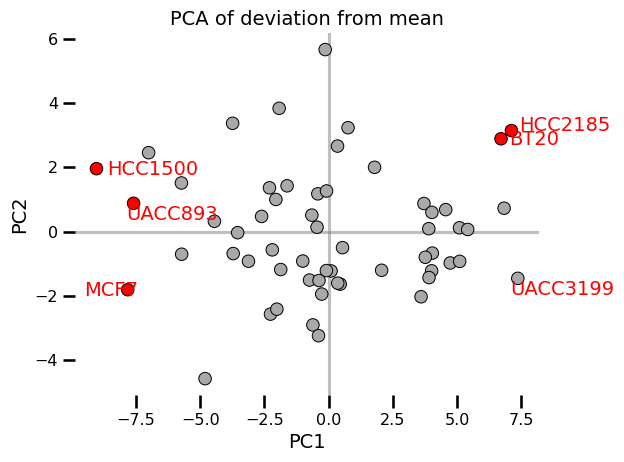

In [19]:
sns.set_context("talk", font_scale=0.7)
g = sns.scatterplot(
    data=df, 
    x="PC1", 
    y="PC2", 
    hue="validation",
    palette={True: "red", False: "darkgray"},
    edgecolor="black",
    legend=False
)
# add red colour for validation cell-lines
for _, r in df.iterrows():
    if r.validation or r.name in offsets.keys():
        plt.annotate(r.name, (r.PC1+offsets[r.name]["ox"], r.PC2+offsets[r.name]["oy"]), color="red", fontsize=14)

# export with transparent background and high dpi, remove grid
# no box around plot
# add dashed line at 0 for both axes with low order to ensure it is behind the data points
# make plot square
# make axis limits equal and remove axis labels
# g.set(xlim=(-7.2, 7.2), ylim=(-5, 5), aspect=1.0, xticks=[], yticks=[])
g.set_xlabel("PC1", fontsize=14)
g.set_ylabel("PC2", fontsize=14)
#
plt.axhline(0, color='gray', zorder=0, alpha=0.5)
plt.axvline(0, color='gray', zorder=0, alpha=0.5)
plt.box(False)
plt.grid(False)
VE = sum(pca.explained_variance_ratio_[:2])
# plt.title(f"PCA of deviance from mean ({VE*100:.0f}% Variance Explained)")
plt.title(f"PCA of deviation from mean", fontsize=14)
plt.tight_layout()
# plt.savefig("cytof_pca.png", transparent=True, dpi=300)


In [20]:
res_df = res.reset_index()
res_df["cell_line"] = res_df["cell_line"].apply(lambda x: x[1:])

scatter_df = df.reset_index().merge(res_df, on="cell_line", how="left")


In [21]:
pca.explained_variance_ratio_

array([0.4889075 , 0.11487537, 0.08108438, 0.07043642, 0.05332   ,
       0.03387251, 0.02327552, 0.01755132, 0.01336049, 0.01153738])

In [22]:
np.cumsum(pca.explained_variance_ratio_)

array([0.4889075 , 0.60378287, 0.68486725, 0.75530367, 0.80862367,
       0.84249618, 0.8657717 , 0.88332303, 0.89668352, 0.9082209 ])

In [23]:
pca.components_.shape

(10, 96)

In [24]:
pc_mat = pd.DataFrame(
    index=[f"PC{i}" for i in np.arange(N_COMPS)],
    data=pca.components_[:N_COMPS, :],
    columns=mat.columns,
)
pc_mat

observableId          pERBB2_Y1248_obs                                \
simulationConditionId              EGF                                 
time                              0.0       5.5       7.0       9.0    
PC0                           0.029656  0.059746  0.056304  0.064026   
PC1                           0.128063  0.156008  0.156657  0.163043   

observableId                                                             \
simulationConditionId                                                     
time                       13.0      17.0      23.0      30.0      40.0   
PC0                    0.059932  0.070147  0.045425  0.061839  0.071602   
PC1                    0.184068  0.146699  0.173195  0.193827  0.178787   

observableId                     ... pRPS6KA1_S380_obs                      \
simulationConditionId            ...             iEGFR                       
time                       60.0  ...              17.0      40.0      60.0   
PC0                    0.072981  ...          0.152208  0.155754  0.167465   
PC1                    0.184683  ...         -0.056474 -0.053794 -0.044029   

observableId                                                             \
simulationConditionId      iMEK                                           
time                       0.0       7.0       9.0       13.0      17.0   
PC0                    0.090332  0.106809  0.132459  0.133453  0.128476   
PC1                    0.060453  0.080413  0.041925  0.001755  0.019477   

observableId                               
simulationConditionId                      
time                       40.0      60.0  
PC0                    0.154368  0.124136  
PC1                    0.028574  0.064611  

[2 rows x 96 columns]

In [25]:
pc_mat_long = pd.melt(pc_mat.reset_index(), id_vars=[("index", "", "")])
pc_mat_long

,"(index, , )",observableId,simulationConditionId,time,value
0,PC0,pERBB2_Y1248_obs,EGF,0.0,0.029656
1,PC1,pERBB2_Y1248_obs,EGF,0.0,0.128063
2,PC0,pERBB2_Y1248_obs,EGF,5.5,0.059746
3,PC1,pERBB2_Y1248_obs,EGF,5.5,0.156008
4,PC0,pERBB2_Y1248_obs,EGF,7.0,0.056304
...,...,...,...,...,...
187,PC1,pRPS6KA1_S380_obs,iMEK,17.0,0.019477
188,PC0,pRPS6KA1_S380_obs,iMEK,40.0,0.154368
189,PC1,pRPS6KA1_S380_obs,iMEK,40.0,0.028574
190,PC0,pRPS6KA1_S380_obs,iMEK,60.0,0.124136


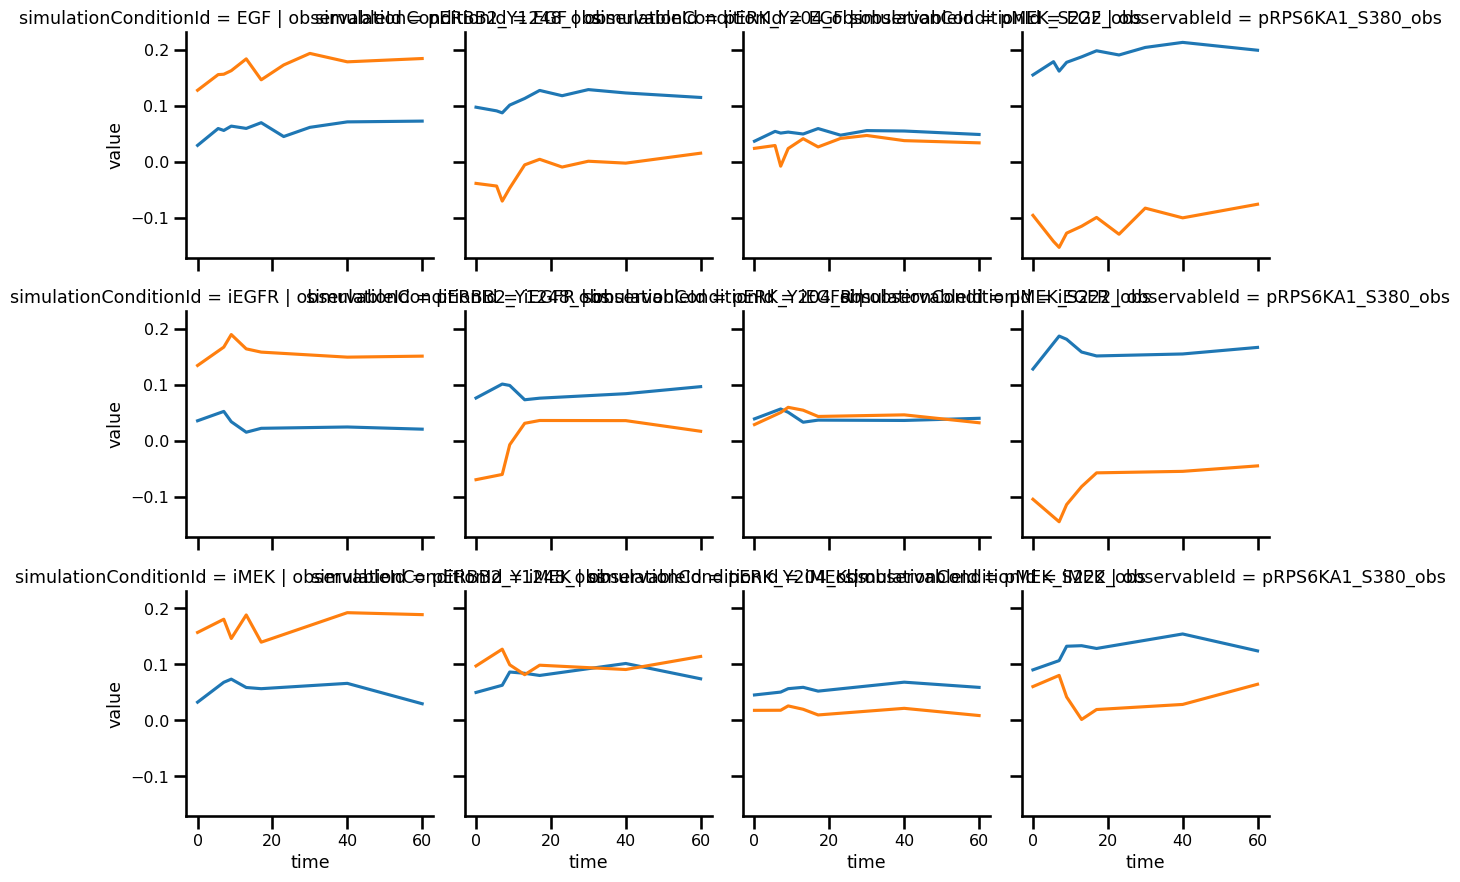

In [26]:
g = sns.FacetGrid(
    data=pc_mat_long,
    col=petab.OBSERVABLE_ID,
    row=petab.SIMULATION_CONDITION_ID,
    hue=("index", "", ""),
)
g.map_dataframe(sns.lineplot, x=petab.TIME, y="value")